# Mammography pathology synthesis (exploratory notebook)

Author: Oluwasegun Isaac Oyekunle (DATICAN Scholar).

Simulates invasive ductal carcinoma, a benign cyst and mucinous carcinoma on a mammogram, and shows the image in the Fourier domain. The two helper cells (*Reconstruction Function*, *Geometric Function*) are adapted from KspaceMRIBO (https://github.com/yihonglilyxu/KspaceMRIBO) and are not used by the synthesis cells.

No image data is stored in this repository; see the README for how to supply the input DICOM.

In [ ]:
pip install torch torchvision matplotlib numpy h5py pydicom scikit-image

In [ ]:
pip install opencv-python

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import torch
import torchvision

import matplotlib.pyplot as plt
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader
import h5py

import fastmri
from fastmri.fftc import fft2c_new, ifft2c_new
from fastmri.math import complex_abs

import pydicom
import skimage
from skimage.transform import resize

# from utils.loss import mse, nmse, psnr, ssim

import math
import time

# Define image size
imgsz = 256
w = 48


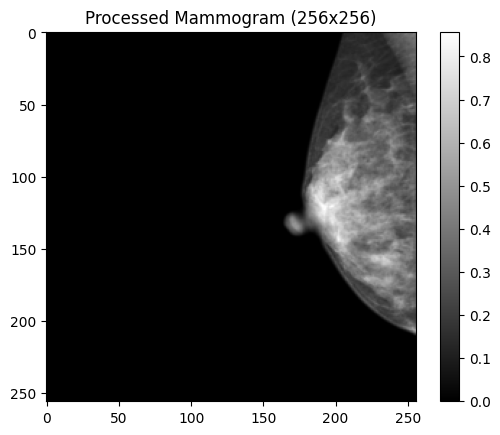

In [ ]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize

# Load DICOM file
file_path = '/content/drive/MyDrive/DATICAN/MSC/StatisticalModel/data/mammo.dcm'
dicom_data = pydicom.dcmread(file_path)

# Extract image data and normalize
im = dicom_data.pixel_array.astype(np.float32)
im = (im - np.min(im)) / (np.max(im) - np.min(im))  # Normalize between 0 and 1

# Resize image to a fixed size (256x256)
im = resize(im, (imgsz, imgsz))

# Display the image
plt.imshow(im, cmap='gray')
plt.colorbar()
plt.title('Processed Mammogram (256x256)')
plt.show()


In [ ]:
######### Reconstruction Function #########

def zerofill_samp(img1_k, ind):
    img_r = fastmri.complex_abs(ifft2c_new(img1_k)).view(-1, 1)
    img_r = img_r.reshape(imgsz, imgsz)
    pixnum = len(ind)
    img1_k_ = img1_k[w:imgsz-w, w:imgsz-w, :]
    picked_r = img1_k_[:, :, 0].reshape(-1, 1)
    picked_i = img1_k_[:, :, 1].reshape(-1, 1)

    for i in range((imgsz-2*w)**2):
        if i not in ind:
            picked_r[i, 0] = 0
            picked_i[i, 0] = 0

    picked_r = picked_r.reshape(imgsz-2*w, imgsz-2*w)
    picked_i = picked_i.reshape(imgsz-2*w, imgsz-2*w)

    picked_k = torch.stack([picked_r, picked_i], dim=2)

    whole_k = torch.zeros(imgsz, imgsz, 2)
    whole_k[w:imgsz-w, w:imgsz-w, :] = picked_k
    rcon = fastmri.complex_abs(ifft2c_new(whole_k))

    nmse_ = nmse(img_r.numpy(), rcon.numpy())
    ssim_ = ssim(img_r.numpy(), rcon.numpy())
    psnr_ = psnr(img_r.numpy(), rcon.numpy())

    return rcon, nmse_, ssim_, psnr_


In [ ]:
######### Geometric Function #########
def mask_of_r(imgsz, r):
    mask = torch.zeros(imgsz, imgsz)
    for i in range(imgsz):
        for j in range(imgsz):
            i_ = i - (imgsz-1)/2
            j_ = j - (imgsz-1)/2
            if (i_**2 + j_**2)**0.5 >= r and (i_**2 + j_**2)**0.5 < r+1:
                mask[i, j] = 1
    return mask

def mask_in_r(imgsz, r):
    mask = torch.zeros(imgsz, imgsz)
    for i in range(imgsz):
        for j in range(imgsz):
            i_ = i - (imgsz-1)/2
            j_ = j - (imgsz-1)/2
            if (i_**2 + j_**2)**0.5 <= r:
                mask[i, j] = 1
    return mask

######### Convert Indices to Image Coordinates #########
def ind_to_xy(ind):
    i = (ind // (imgsz - 2*w))
    j = (ind % (imgsz - 2*w))
    y = (imgsz - 2*w - 1 - i) - (imgsz - 2*w - 1) / 2
    x = j - (imgsz - 2*w - 1) / 2
    return x, y


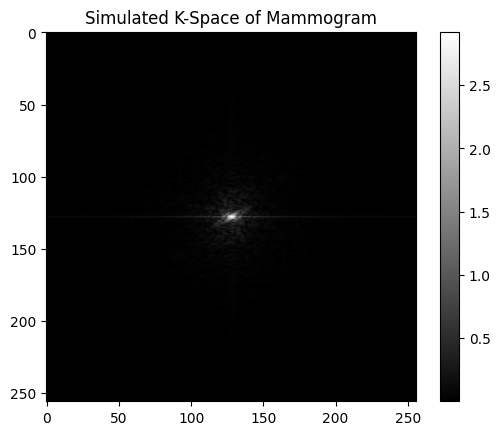

In [ ]:
import numpy as np
import torch
import fastmri
from fastmri.fftc import fft2c_new, ifft2c_new
import matplotlib.pyplot as plt

# Assuming 'im' is your mammogram image (2D numpy array)
im_tensor = torch.tensor(im, dtype=torch.float32)

# Ensure the image is properly shaped for FastMRI (batch, height, width, complex-dim)
im_tensor = im_tensor.unsqueeze(0).unsqueeze(0)  # Add batch and channel dims
im_tensor = torch.stack((im_tensor, torch.zeros_like(im_tensor)), dim=-1)  # Add complex dim

# Simulate k-space
im_k = fft2c_new(im_tensor)  # Apply 2D FFT
im_k_abs = fastmri.complex_abs(im_k).squeeze().numpy()

# Display k-space magnitude
plt.imshow(np.log1p(im_k_abs), cmap='gray')
plt.colorbar()
plt.title('Simulated K-Space of Mammogram')
plt.show()

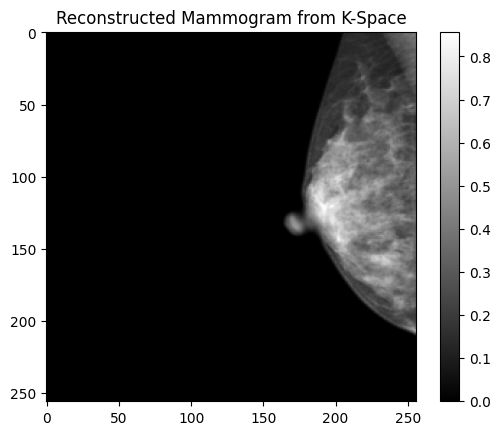

In [ ]:
# Perform inverse FFT (zero-filling reconstruction)
reconstructed_im = fastmri.complex_abs(ifft2c_new(im_k)).squeeze().numpy()

# Display reconstructed image
plt.imshow(reconstructed_im, cmap='gray')
plt.colorbar()
plt.title('Reconstructed Mammogram from K-Space')
plt.show()


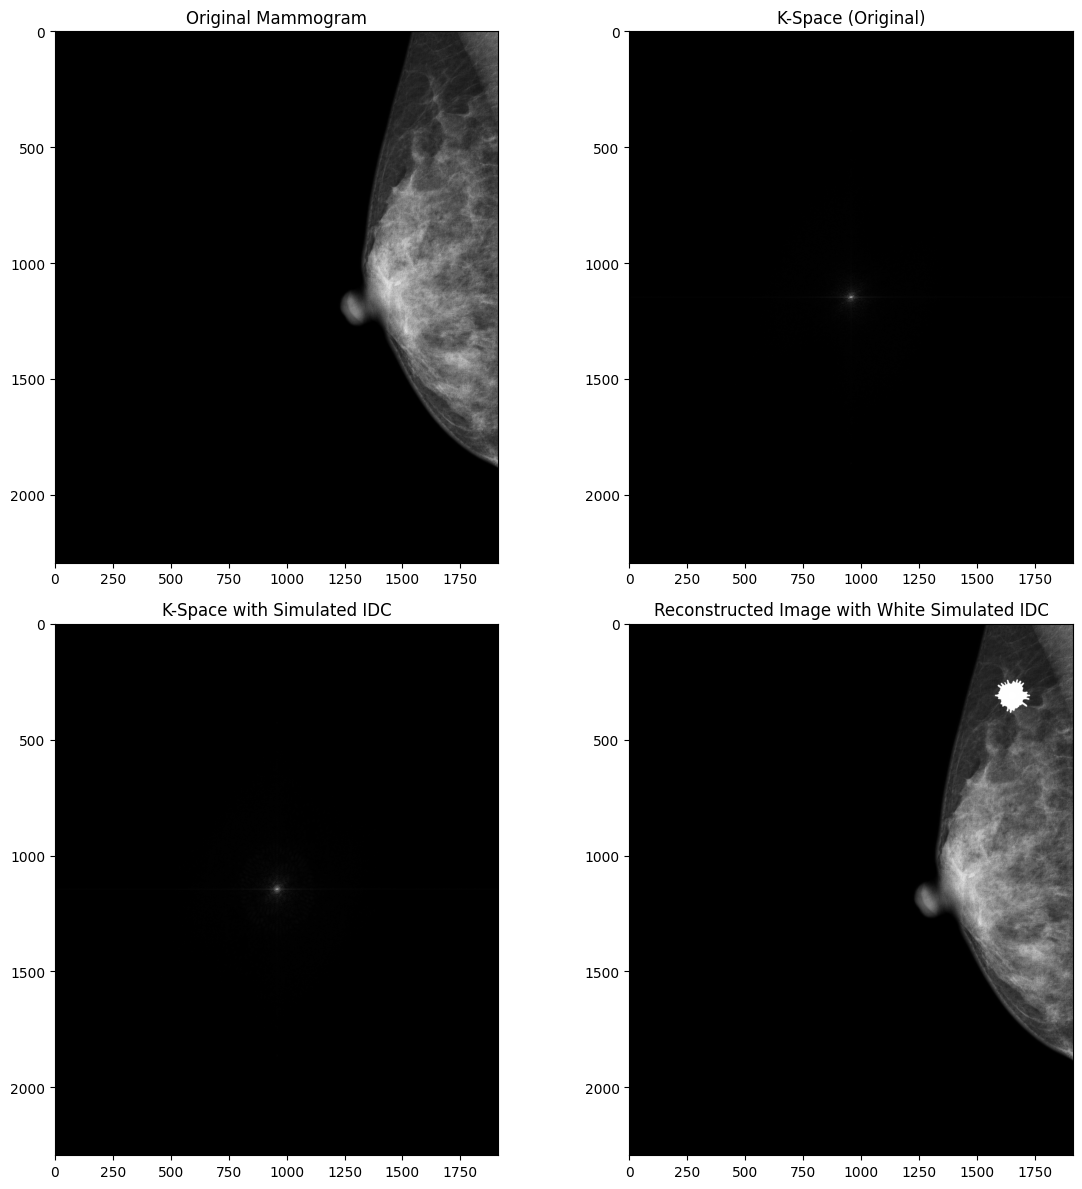

In [ ]:
import numpy as np
import torch
import fastmri
from fastmri.fftc import fft2c_new, ifft2c_new
import matplotlib.pyplot as plt
import pydicom
import cv2

# Load DICOM image (Replace 'your_mammo.dcm' with actual file path)
dcm = pydicom.dcmread(file_path)
im = dcm.pixel_array.astype(np.float32)
im = (im - im.min()) / (im.max() - im.min())  # Normalize image (0 to 1)

# Convert image to PyTorch tensor
im_tensor = torch.tensor(im, dtype=torch.float32)

# Convert to complex tensor with explicit real and imaginary parts
im_complex = torch.stack((im_tensor, torch.zeros_like(im_tensor)), dim=-1)  # Shape: (H, W, 2)

# Reshape to match FastMRI format: (batch, channels, height, width, complex_dim)
im_complex = im_complex.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, H, W, 2)

# Apply FFT to get original k-space
im_k = fft2c_new(im_complex)
im_k_abs = fastmri.complex_abs(im_k).squeeze().numpy()

# Detect breast region using intensity thresholding
breast_mask = im > 0.1  # Threshold to detect breast
coords = np.column_stack(np.where(breast_mask))  # Get nonzero coordinates

# Select a random point inside the breast for IDC simulation
np.random.seed(1)
tumor_center = coords[np.random.randint(len(coords))]  # Pick random point in breast
cy, cx = tumor_center

# Generate an irregular spiculated mass for IDC
idc_mask = np.zeros_like(im)
radius = 60  # Base size of the tumor
num_spikes = 30  # More spikes for realistic IDC
angle_step = 360 / num_spikes

# Draw star-like edges
for i in range(num_spikes):
    angle = np.deg2rad(i * angle_step)
    r_offset = np.random.uniform(-10, 20)  # Randomize spike length
    x_offset = int((radius + r_offset) * np.cos(angle))
    y_offset = int((radius + r_offset) * np.sin(angle))
    cv2.line(idc_mask, (cx, cy), (cx + x_offset, cy + y_offset), 1, 2)

# Fill the tumor area
idc_mask = cv2.GaussianBlur(idc_mask, (15, 15), 5)
idc_mask = (idc_mask > 0.2).astype(np.float32)

# Make IDC mass brighter to stand out
idc_mask *= 2.0  # Increase brightness of the IDC area

# Blend IDC into the image
im_with_idc = im + 0.7 * idc_mask  # Simulate high-density tumor
im_with_idc = np.clip(im_with_idc, 0, 1)  # Keep values in range

# Convert modified image to complex tensor
im_with_idc_tensor = torch.tensor(im_with_idc, dtype=torch.float32)
im_with_idc_complex = torch.stack((im_with_idc_tensor, torch.zeros_like(im_with_idc_tensor)), dim=-1)  # Shape: (H, W, 2)
im_with_idc_complex = im_with_idc_complex.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, H, W, 2)

# Apply FFT to modified image
im_k_with_idc = fft2c_new(im_with_idc_complex)
im_k_with_idc_abs = fastmri.complex_abs(im_k_with_idc).squeeze().numpy()

# Reconstruct image from modified k-space
reconstructed_with_idc = ifft2c_new(im_k_with_idc).squeeze().numpy()
reconstructed_with_idc_real = reconstructed_with_idc[..., 0]  # Take only real part

# Convert to RGB for visualization
reconstructed_rgb = np.stack([reconstructed_with_idc_real] * 3, axis=-1)  # Grayscale to RGB

# Overlay white dot on tumor
tumor_radius = 15  # Adjust tumor marking size
cv2.circle(reconstructed_rgb, (cx, cy), tumor_radius, (1, 1, 1), -1)  # White filled dot

# Display results
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Original Mammogram
axes[0, 0].imshow(im, cmap='gray')
axes[0, 0].set_title("Original Mammogram")

# Original K-Space
axes[0, 1].imshow(np.log1p(im_k_abs), cmap='gray')
axes[0, 1].set_title("K-Space (Original)")

# K-Space with IDC
axes[1, 0].imshow(np.log1p(im_k_with_idc_abs), cmap='gray')
axes[1, 0].set_title("K-Space with Simulated IDC")

# Reconstructed Image with IDC Highlighted
axes[1, 1].imshow(reconstructed_rgb)
axes[1, 1].set_title("Reconstructed Image with White Simulated IDC")

plt.tight_layout()
plt.show()

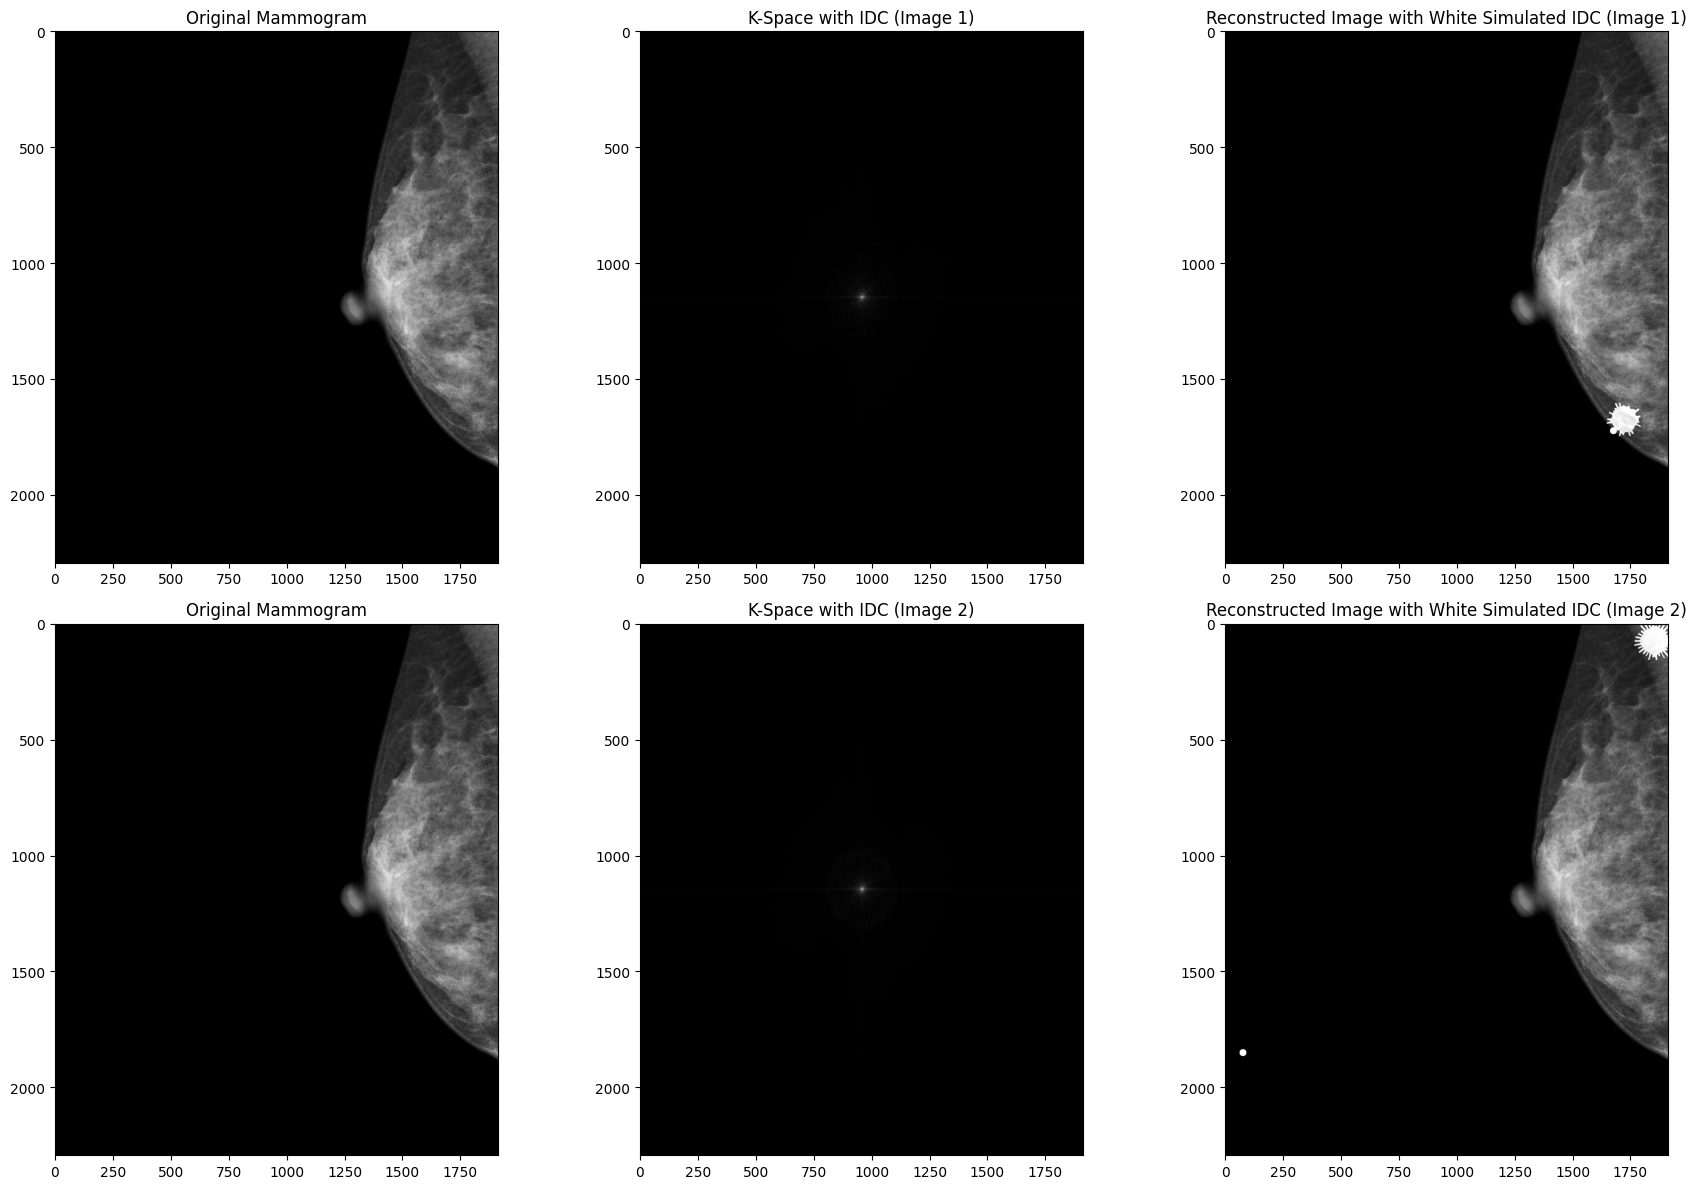

In [ ]:
import numpy as np
import torch
import fastmri
from fastmri.fftc import fft2c_new, ifft2c_new
import matplotlib.pyplot as plt
import pydicom
import cv2

# Load DICOM image (Replace 'your_mammo.dcm' with actual file path)
dcm = pydicom.dcmread(file_path)
im = dcm.pixel_array.astype(np.float32)
im = (im - im.min()) / (im.max() - im.min())  # Normalize image (0 to 1)

# Convert image to PyTorch tensor
im_tensor = torch.tensor(im, dtype=torch.float32)

# Convert to complex tensor with explicit real and imaginary parts
im_complex = torch.stack((im_tensor, torch.zeros_like(im_tensor)), dim=-1)  # Shape: (H, W, 2)
im_complex = im_complex.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, H, W, 2)

# Apply FFT to get original k-space
im_k = fft2c_new(im_complex)
im_k_abs = fastmri.complex_abs(im_k).squeeze().numpy()

# Detect breast region using intensity thresholding
breast_mask = im > 0.1  # Threshold to detect breast
coords = np.column_stack(np.where(breast_mask))  # Get nonzero coordinates

def add_random_idc(image, seed=None):
    """ Add a randomly placed IDC tumor within the breast region """
    if seed is not None:
        np.random.seed(seed)

    # Select a random point inside the breast
    tumor_center = coords[np.random.randint(len(coords))]  # Pick random point in breast
    cy, cx = tumor_center

    # Generate an irregular spiculated mass for IDC
    idc_mask = np.zeros_like(image)
    radius = np.random.randint(40, 80)  # Vary tumor size randomly
    num_spikes = 30  # More spikes for realistic IDC
    angle_step = 360 / num_spikes

    # Draw star-like edges
    for i in range(num_spikes):
        angle = np.deg2rad(i * angle_step)
        r_offset = np.random.uniform(-10, 20)  # Randomize spike length
        x_offset = int((radius + r_offset) * np.cos(angle))
        y_offset = int((radius + r_offset) * np.sin(angle))
        cv2.line(idc_mask, (cx, cy), (cx + x_offset, cy + y_offset), 1, 2)

    # Fill the tumor area
    idc_mask = cv2.GaussianBlur(idc_mask, (15, 15), 5)
    idc_mask = (idc_mask > 0.2).astype(np.float32)

    # Make IDC mass brighter to stand out
    idc_mask *= 1.0  # Increase brightness of the IDC area

    # Blend IDC into the image
    image_with_idc = image + 0.7 * idc_mask  # Simulate high-density tumor
    image_with_idc = np.clip(image_with_idc, 0, 1)  # Keep values in range

    return image_with_idc, (cx, cy)

# Generate two images with different IDC placements
im_with_idc_1, tumor_center_1 = add_random_idc(im, seed=np.random.randint(0, 1000))
im_with_idc_2, tumor_center_2 = add_random_idc(im, seed=np.random.randint(0, 1000))

# Convert images to complex tensors
im_with_idc_tensor_1 = torch.tensor(im_with_idc_1, dtype=torch.float32)
im_with_idc_complex_1 = torch.stack((im_with_idc_tensor_1, torch.zeros_like(im_with_idc_tensor_1)), dim=-1)
im_with_idc_complex_1 = im_with_idc_complex_1.unsqueeze(0).unsqueeze(0)

im_with_idc_tensor_2 = torch.tensor(im_with_idc_2, dtype=torch.float32)
im_with_idc_complex_2 = torch.stack((im_with_idc_tensor_2, torch.zeros_like(im_with_idc_tensor_2)), dim=-1)
im_with_idc_complex_2 = im_with_idc_complex_2.unsqueeze(0).unsqueeze(0)

# Apply FFT to both images
im_k_with_idc_1 = fft2c_new(im_with_idc_complex_1)
im_k_with_idc_abs_1 = fastmri.complex_abs(im_k_with_idc_1).squeeze().numpy()

im_k_with_idc_2 = fft2c_new(im_with_idc_complex_2)
im_k_with_idc_abs_2 = fastmri.complex_abs(im_k_with_idc_2).squeeze().numpy()

# Reconstruct images from modified k-space
reconstructed_with_idc_1 = ifft2c_new(im_k_with_idc_1).squeeze().numpy()[..., 0]  # Take only real part
reconstructed_with_idc_2 = ifft2c_new(im_k_with_idc_2).squeeze().numpy()[..., 0]  # Take only real part

# Convert to RGB for visualization
reconstructed_rgb_1 = np.stack([reconstructed_with_idc_1] * 3, axis=-1)
reconstructed_rgb_2 = np.stack([reconstructed_with_idc_2] * 3, axis=-1)

# Overlay white dot on tumor locations
tumor_radius = 15  # Adjust tumor marking size
cv2.circle(reconstructed_rgb_1, tumor_center_1[::-1], tumor_radius, (1, 1, 1), -1)  # White filled dot
cv2.circle(reconstructed_rgb_2, tumor_center_2[::-1], tumor_radius, (1, 1, 1), -1)  # White filled dot

# Display results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# First Image Set
axes[0, 0].imshow(im, cmap='gray')
axes[0, 0].set_title("Original Mammogram")

axes[0, 1].imshow(np.log1p(im_k_with_idc_abs_1), cmap='gray')
axes[0, 1].set_title("K-Space with IDC (Image 1)")

axes[0, 2].imshow(reconstructed_rgb_1)
axes[0, 2].set_title("Reconstructed Image with White Simulated IDC (Image 1)")

# Second Image Set
axes[1, 0].imshow(im, cmap='gray')
axes[1, 0].set_title("Original Mammogram")

axes[1, 1].imshow(np.log1p(im_k_with_idc_abs_2), cmap='gray')
axes[1, 1].set_title("K-Space with IDC (Image 2)")

axes[1, 2].imshow(reconstructed_rgb_2)
axes[1, 2].set_title("Reconstructed Image with White Simulated IDC (Image 2)")

plt.tight_layout()
plt.show()


**The above is for Invasive Ductal Carcinoma (IDC)**

**The below is a cyst (Benign)**

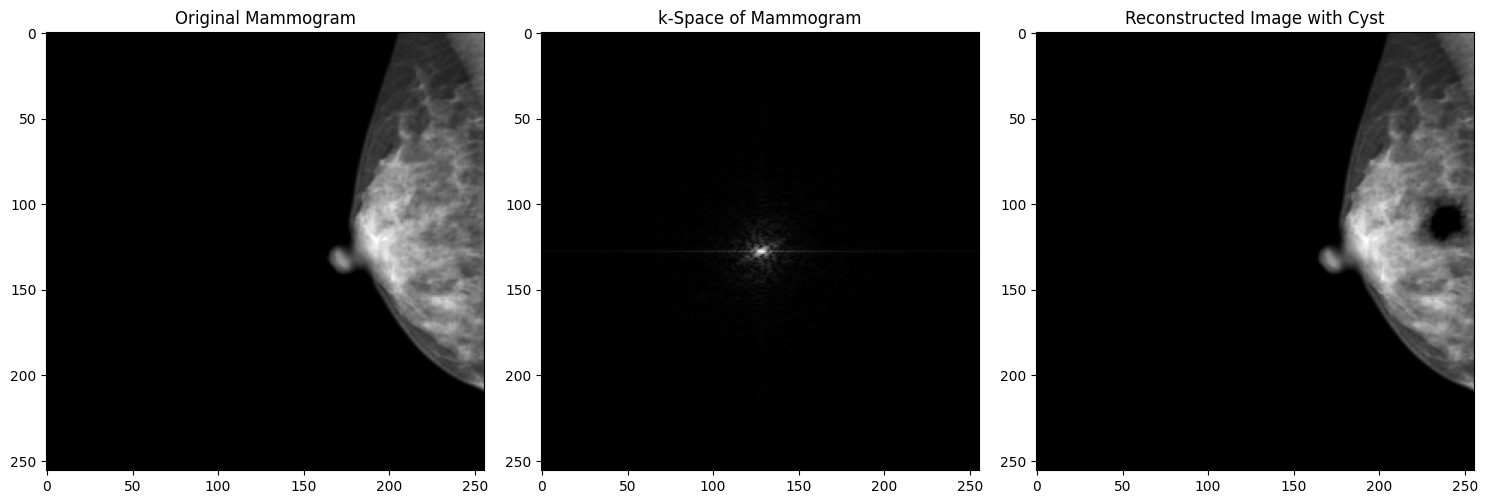

In [ ]:
##### Import Libraries #####
import os
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import random
from torch.utils.data import Dataset, DataLoader
import h5py
import fastmri
from fastmri.fftc import fft2c_new, ifft2c_new
from fastmri.math import complex_abs
import pydicom
import cv2
from skimage.transform import resize

##### Load and Process DICOM Mammogram #####
file_path = '/content/drive/MyDrive/DATICAN/MSC/StatisticalModel/data/mammo.dcm'
dicom_data = pydicom.dcmread(file_path)

# Extract and normalize image
target_size = 256
im = dicom_data.pixel_array.astype(np.float32)
im = (im - np.min(im)) / (np.max(im) - np.min(im))  # Normalize 0-1
im = resize(im, (target_size, target_size))  # Resize to 256x256

##### Simulate a Benign Cyst #####
# Select random cyst center inside breast tissue
breast_mask = im > 0.1  # Detect breast area
coords = np.column_stack(np.where(breast_mask))  # Get nonzero coordinates
np.random.seed(2)
cyst_center = coords[np.random.randint(len(coords))]
cy, cx = cyst_center

# Generate round, well-defined cyst mask
cyst_mask = np.zeros_like(im)
cyst_radius = 10  # Moderate cyst size
cv2.circle(cyst_mask, (cx, cy), cyst_radius, 1, -1)

# Simulate cyst properties
cyst_mask = cv2.GaussianBlur(cyst_mask, (21, 21), 6)  # Soft edges
cyst_mask *= -0.7  # Decrease brightness to mimic fluid appearance

# Blend cyst into mammogram
im_with_cyst = im + cyst_mask
im_with_cyst = np.clip(im_with_cyst, 0, 1)

##### Convert Image to k-Space #####
# Convert to PyTorch tensor
im_tensor = torch.tensor(im_with_cyst, dtype=torch.float32)
im_tensor = torch.stack((im_tensor, torch.zeros_like(im_tensor)), dim=-1)  # Complex format
im_tensor = im_tensor.unsqueeze(0).unsqueeze(0)  # Shape (1, 1, H, W, 2)

# Apply FFT to get k-space
im_k = fft2c_new(im_tensor)
im_k_abs = fastmri.complex_abs(im_k).squeeze().numpy()

##### Reconstruct Image from k-Space #####
reconstructed_im = fastmri.complex_abs(ifft2c_new(im_k)).squeeze().numpy()

##### Display Results #####
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original Mammogram
axes[0].imshow(im, cmap='gray')
axes[0].set_title("Original Mammogram")

# k-Space
axes[1].imshow(np.log1p(im_k_abs), cmap='gray')
axes[1].set_title("k-Space of Mammogram")

# Reconstructed Image with Cyst
axes[2].imshow(reconstructed_im, cmap='gray')
axes[2].set_title("Reconstructed Image with Cyst")

plt.tight_layout()
plt.show()


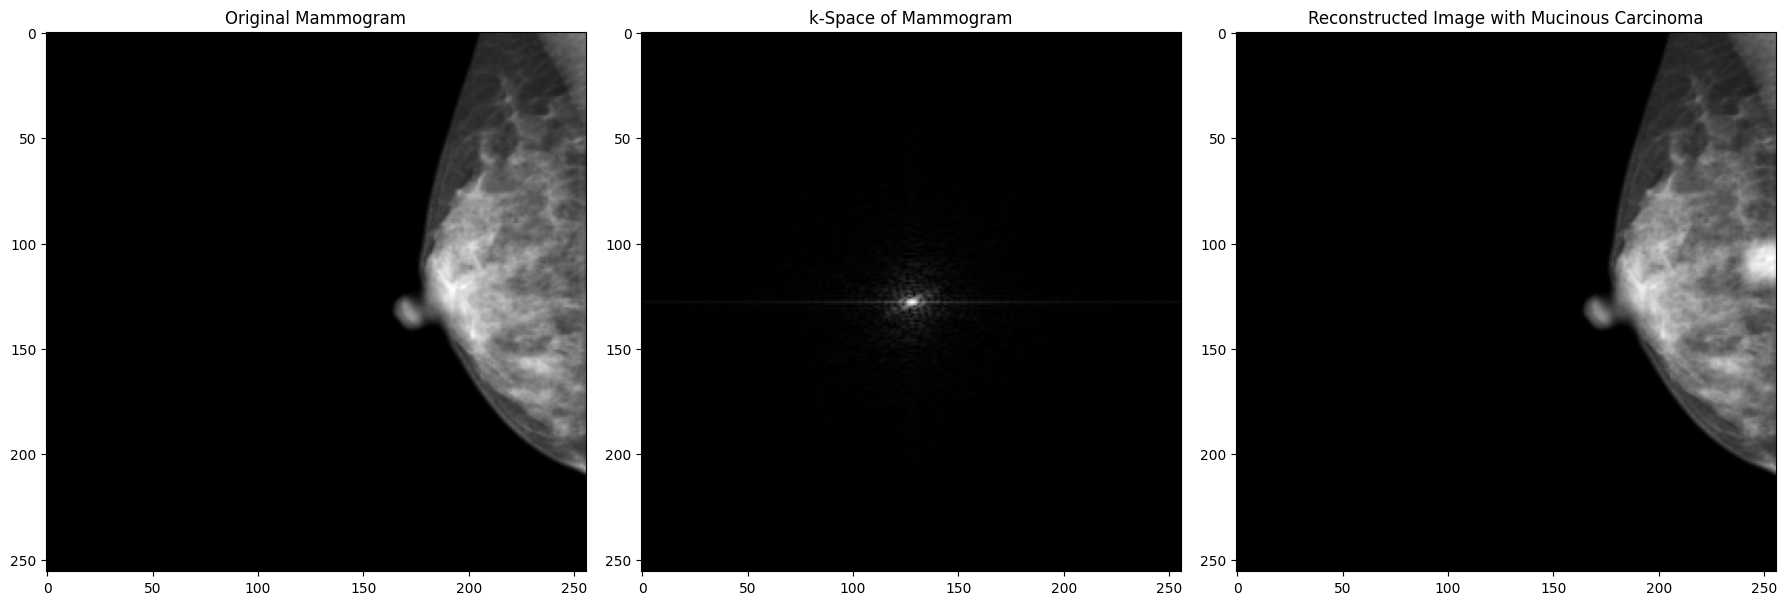

In [ ]:
##### Import Libraries #####
import os
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import random
from torch.utils.data import Dataset, DataLoader
import h5py
import fastmri
from fastmri.fftc import fft2c_new, ifft2c_new
from fastmri.math import complex_abs
import pydicom
import cv2
from skimage.transform import resize

##### Load and Process DICOM Mammogram #####
file_path = '/content/drive/MyDrive/DATICAN/MSC/StatisticalModel/data/mammo.dcm'
dicom_data = pydicom.dcmread(file_path)

# Extract and normalize image
target_size = 256
im = dicom_data.pixel_array.astype(np.float32)
im = (im - np.min(im)) / (np.max(im) - np.min(im))  # Normalize 0-1
im = resize(im, (target_size, target_size))  # Resize to 256x256

##### Simulate Mucinous Carcinoma #####
# Select a random tumor center inside the breast tissue
breast_mask = im > 0.1  # Detect breast area
coords = np.column_stack(np.where(breast_mask))  # Get nonzero coordinates
np.random.seed(42)
tumor_center = coords[np.random.randint(len(coords))]
cy, cx = tumor_center

# Generate round, lobulated mass
tumor_mask = np.zeros_like(im)
tumor_radius = 10  # Moderate, not too big
cv2.circle(tumor_mask, (cx, cy), tumor_radius, 1, -1)

# Introduce slight lobulation for realism
tumor_mask = cv2.GaussianBlur(tumor_mask, (13, 13), 3)

# Adjust intensity for **low-to-intermediate density** (not too dark like cyst, not bright white)
tumor_mask *= 0.6  # Lighter gray appearance

# Create a soft "halo effect" around the tumor (pseudo-capsule)
halo = cv2.GaussianBlur(tumor_mask, (21, 21), 7)
halo *= -0.2  # Slight shadow around tumor for realism

# Blend tumor into mammogram
im_mucinous = im + tumor_mask + halo
im_mucinous = np.clip(im_mucinous, 0, 1)

##### Convert Image to k-Space #####
# Convert to PyTorch tensor with complex components
im_tensor = torch.tensor(im_mucinous, dtype=torch.float32)
im_complex = torch.stack((im_tensor, torch.zeros_like(im_tensor)), dim=-1)  # Convert to complex format
im_complex = im_complex.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, H, W, 2)

# Apply FFT to get k-space
im_k = fft2c_new(im_complex)
im_k_abs = fastmri.complex_abs(im_k).squeeze().numpy()

##### Reconstruct Image from k-Space #####
reconstructed_complex = ifft2c_new(im_k)
reconstructed_im = fastmri.complex_abs(reconstructed_complex).squeeze().numpy()

##### Display Results #####
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original Mammogram
axes[0].imshow(im, cmap='gray')
axes[0].set_title("Original Mammogram")

# k-Space
axes[1].imshow(np.log1p(im_k_abs), cmap='gray')
axes[1].set_title("k-Space of Mammogram")

# Reconstructed Image with Mucinous Carcinoma
axes[2].imshow(reconstructed_im, cmap='gray')
axes[2].set_title("Reconstructed Image with Mucinous Carcinoma")

plt.tight_layout()
plt.show()


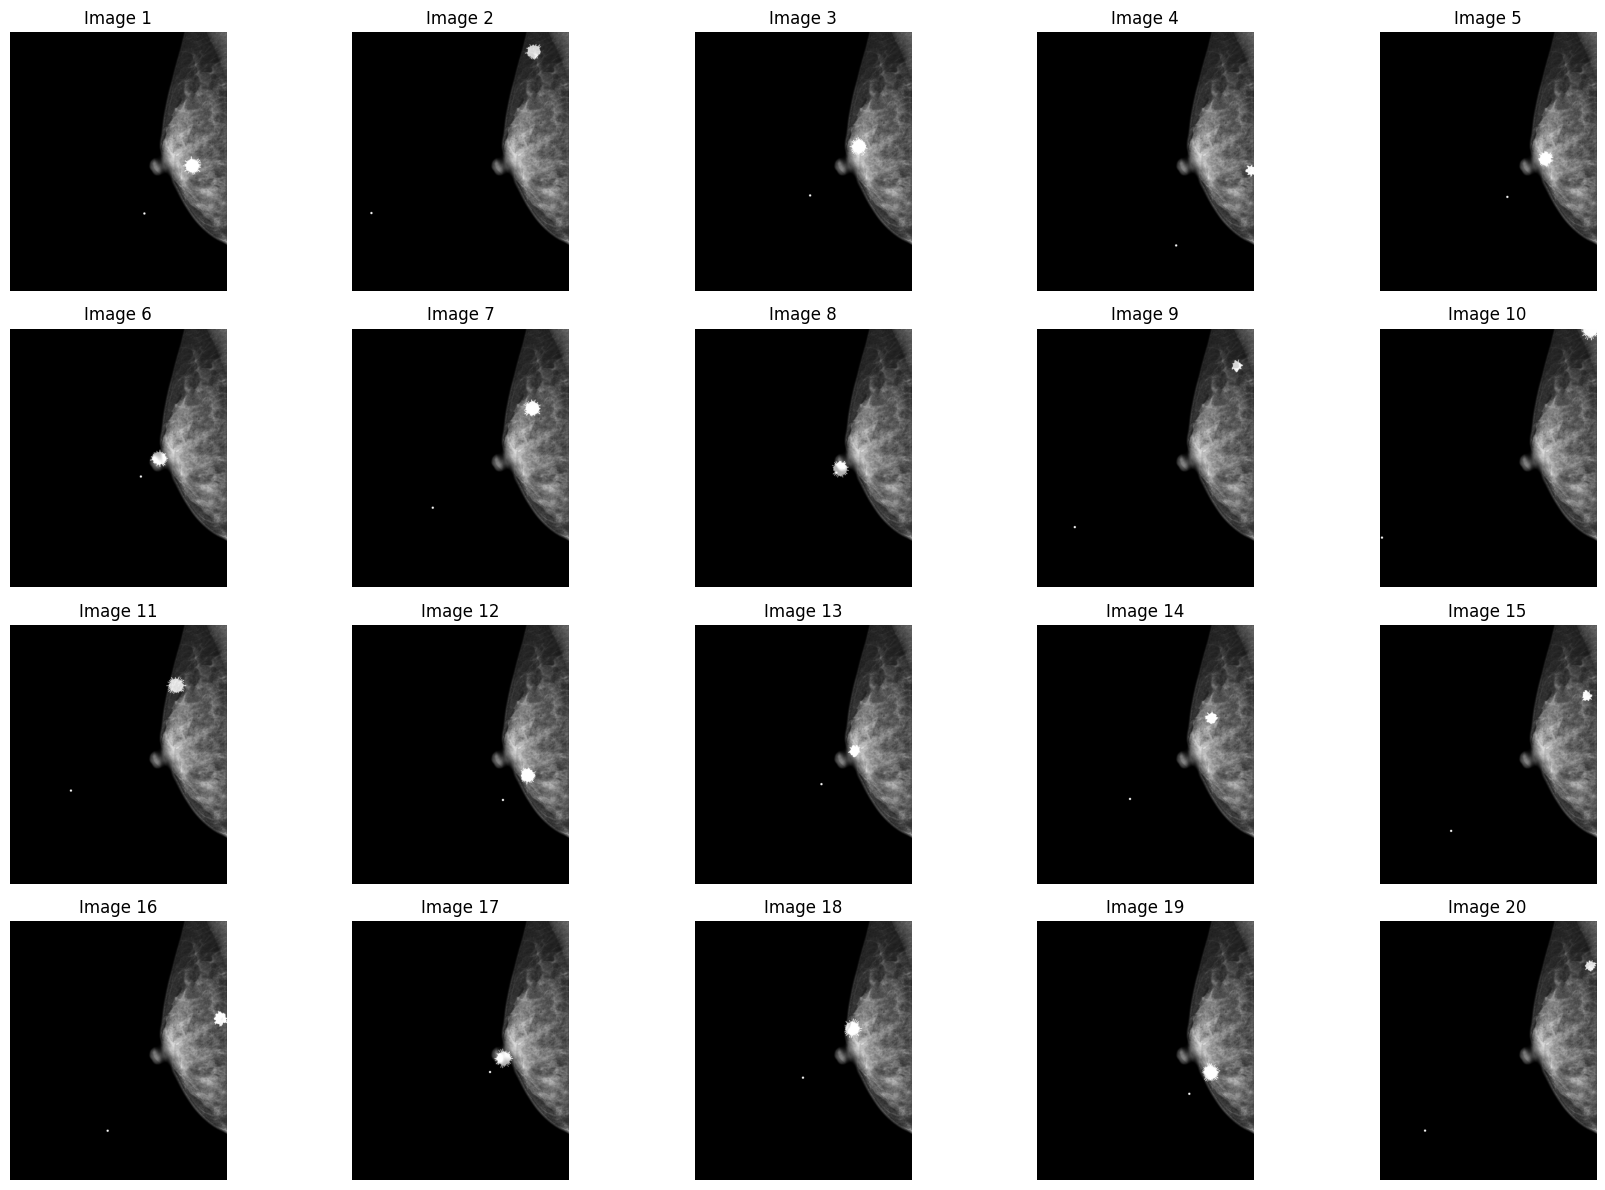

In [ ]:
# Generate and visualize 20 synthetic mammograms with pathology
fig, axes = plt.subplots(4, 5, figsize=(18, 12))

for i in range(20):
    # Generate a synthetic pathology
    im_with_pathology, tumor_center = add_random_idc(im, seed=np.random.randint(0, 1000))

    # Convert to RGB for visualization
    im_rgb = np.stack([im_with_pathology] * 3, axis=-1)

    # Mark tumor location
    cv2.circle(im_rgb, tumor_center[::-1], 10, (1, 1, 1), -1)  # White dot

    # Plot the image
    ax = axes[i // 5, i % 5]
    ax.imshow(im_rgb, cmap='gray')
    ax.set_title(f"Image {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import os

# Create a directory to save images
output_dir = "synthetic_mammograms"
os.makedirs(output_dir, exist_ok=True)

for i in range(100):
    # Generate a synthetic pathology
    im_with_pathology, tumor_center = add_random_idc(im, seed=np.random.randint(0, 1000))

    # Convert to RGB for visualization
    im_rgb = np.stack([im_with_pathology] * 3, axis=-1)

    # Mark tumor location
    cv2.circle(im_rgb, tumor_center[::-1], 10, (1, 1, 1), -1)  # White dot

    # Save the image
    filename = os.path.join(output_dir, f"mammogram_{i+1}.png")
    plt.imsave(filename, im_rgb, cmap='gray')

print("100 synthetic mammogram images generated and saved successfully!")


100 synthetic mammogram images generated and saved successfully!


In [ ]:
import os
print("Saving to:", os.getcwd())  # Prints the current directory


Saving to: /content
